/tmp/ipykernel_13372/1365944928.py:21: DtypeWarning: Columns (0: driving_cell_strength) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{dataset_path}/{block}/features/nets_load_features.csv", sep=',')
/tmp/ipykernel_13372/1365944928.py:21: DtypeWarning: Columns (0: driving_cell_strength) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{dataset_path}/{block}/features/nets_load_features.csv", sep=',')
/tmp/ipykernel_13372/1365944928.py:21: DtypeWarning: Columns (0: driving_cell_strength) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{dataset_path}/{block}/features/nets_load_features.csv", sep=',')
/tmp/ipykernel_13372/1365944928.py:21: DtypeWarning: Columns (0: driving_cell_strength) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{dataset_path}/{block}/features/nets_load_features.csv", sep=',')
/tmp

Всего уникальных блоков: 45
Всего блоков: 45
Количество фолдов: 9
Блоков в обучении на фолд: 40
Блоков в тесте на фолд: 5

--- Фолд 1 ---
Тренировочные блоки (40): ['sha256' 'xtea' 'MC6803_gen2' 'wb_conmax_top' 'Md5Core' 'usb_phy' 'gng'
 'mc_top' 'lfsr' 'spi_top' 'point_scalar_mult' 'MIPS32_Processor'
 'BRSFmnCE' 'USFFT64_2B' 'tv80s' 'RS_dec' 'des3' 'ima_adpcm_enc'
 'simple_spi_top' 'pcm_slv_top' 'i2c_master_top' 'sasc_top' 'ac97_top'
 'aes_cipher_top' 'jpeg_encoder' 'wbqspiflash' 'aes_core' 'FIR_filter'
 'idft_top' 'dynamic_node_top_wrap' 'uart_top' 'ima_adpcm_dec' 'spiMaster'
 'vga_enh_top' 'fht' 'aes128_core' 'IIR_filter' 'pci_bridge32'
 'trigonometric' 'wb_dma_top']
Тестовые блоки (5): ['xge_mac' 'picosoc' 'keccak' 'dmx_tx' 'sdrc_top']
Тренировочные samples: 894587
Тестовые samples: 171020
MSE: 2.7915
MAE: 0.3401
MAPE: 0.9083
R²: 0.9645

--- Фолд 2 ---
Тренировочные блоки (40): ['xge_mac' 'picosoc' 'keccak' 'dmx_tx' 'sdrc_top' 'usb_phy' 'gng' 'mc_top'
 'lfsr' 'spi_top' 'point_scala

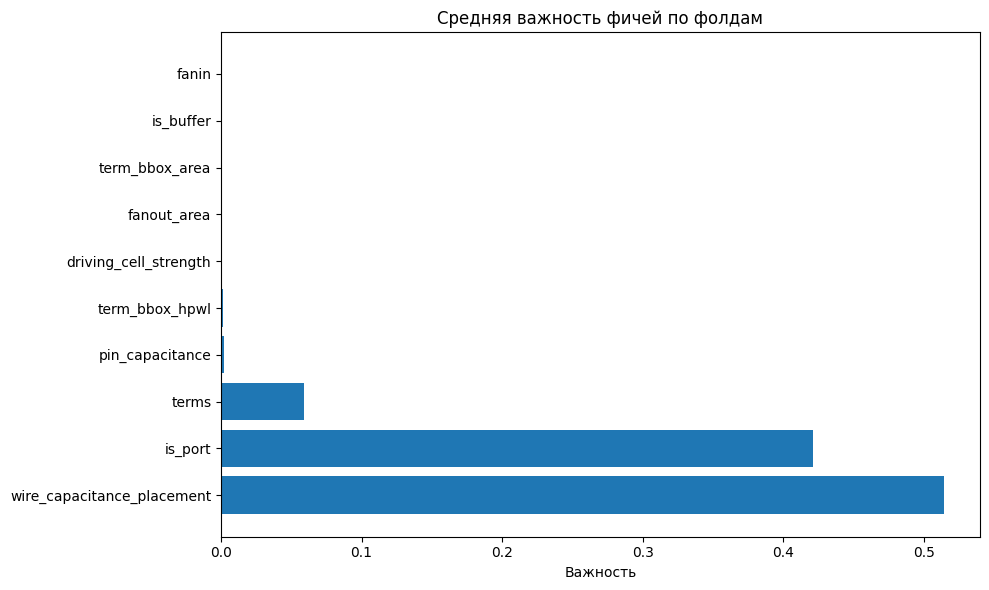


Обучение финальной модели на всех данных...
Финальная модель обучена!


In [96]:
#MY XGB
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import xgboost as xgb
from sklearn.preprocessing import StandardScaler

# get blocks
dataset_path = "/home/nzheludkov/phd/ml-critical-path-prediction/dataset/load_prediction"
items = os.listdir(dataset_path)
blocks = [item for item in items if os.path.isdir(os.path.join(dataset_path, item))]

df_blocks_list = []
block_names = []

for block in blocks:
    
    # get nets_load_features.csv (feate store)
    df = pd.read_csv(f"{dataset_path}/{block}/features/nets_load_features.csv", sep=',')

    #get net labels
    df_y = pd.read_csv(f"{dataset_path}/{block}/labels/nets_load_labels.csv", sep=',')

    #fix driving_cell_strength column
    df["driving_cell_strength"] = df["driving_cell_strength"].fillna(0.0)
    df['driving_cell_strength'] = df['driving_cell_strength'].replace('port', -1)
    
    # drop all Nan rows
    df = df.dropna()
    
    # drop bad features term_bbox_xmin, term_bbox_ymin, term_bbox_xmax, term_bbox_ymax, term_bbox_dy, term_bbox_dx
    #driving_inst, driving_cell 
    df = df.drop(columns=['term_bbox_xmin', 'term_bbox_ymin', 'term_bbox_xmax', 
                         'term_bbox_ymax', 'term_bbox_dy', 'term_bbox_dx', 'driving_inst', 'driving_cell'])

    #merge feats and labels
    df = df.merge(df_y, on="net")

    #transfer capacintece from F to fF
    df['pin_capacitance'] = df['pin_capacitance'] * 1e15
    df['wire_capacitance_placement'] = df['wire_capacitance_placement'] * 1e15
    df['wire_capacitance_spef'] = df['wire_capacitance_spef'] * 1e15

    #change 0 ff wire_capacitance_spef with 0.1 ff
    df['wire_capacitance_spef'] = df['wire_capacitance_spef'].replace(0, 0.001)

    # Add block identifier
    df['block_id'] = block

    #drop nets no routes
    df['routed_length'] = pd.to_numeric(df['routed_length'], errors='coerce')
    df = df.dropna(subset=['routed_length'])
    
    # append df to common df
    df_blocks_list.append(df)
    block_names.append(block)

# create common df
df = pd.concat(df_blocks_list, ignore_index=True)

# Определяем фичи и таргет
#features = [col for col in df.columns if col not in ['cap', 'block_id']]
#features = ['terms', 'is_port', 'term_bbox_area', 'term_bbox_hpwl', 
#            'wire_capacitance_placement', 'pin_capacitance', 'driving_cell_strength', 
#            'is_buffer', 'fanin', 'fanout_area']

#features = [col for col in df.columns if col not in ['cap', 'block_id']]
features = ['terms', 'is_port', 'term_bbox_area', 'term_bbox_hpwl', 
             'pin_capacitance', 'driving_cell_strength', 
            'is_buffer', 'fanin', 'fanout_area', 'wire_capacitance_placement']

X = df[features]
y = df['wire_capacitance_spef']
groups = df['block_id']

# Проверяем количество уникальных блоков
unique_blocks = df['block_id'].unique()
print(f"Всего уникальных блоков: {len(unique_blocks)}")

# Создаем кастомную стратегию для N фолдов
n_splits = 9
n_blocks_total = len(unique_blocks)
n_test_blocks = round(n_blocks_total / n_splits)
n_train_blocks = n_blocks_total - n_test_blocks
n_test_blocks, n_train_blocks

print(f"Всего блоков: {n_blocks_total}")
print(f"Количество фолдов: {n_splits}")
print(f"Блоков в обучении на фолд: {n_train_blocks}")
print(f"Блоков в тесте на фолд: {n_test_blocks}")

# Случайно перемешиваем блоки для разнообразия фолдов
np.random.seed(42)
shuffled_blocks = np.random.permutation(unique_blocks)

# Метрики для хранения результатов
mse_scores = []
mae_scores = []
mape_scores = []
r2_scores = []
feature_importances = []

# Кастомная кросс-валидация по блокам
for fold in range(n_splits):
    print(f"\n--- Фолд {fold + 1} ---")
    
    # Вычисляем индексы для тестовых блоков (скользящее окно)
    start_idx = fold * n_test_blocks
    end_idx = start_idx + n_test_blocks
    
    # Если вышли за границы, начинаем сначала
    if end_idx > n_blocks_total:
        start_idx = 0
        end_idx = n_test_blocks
    
    test_blocks = shuffled_blocks[start_idx:end_idx]
    train_blocks = np.array([block for block in shuffled_blocks if block not in test_blocks])
    
    print(f"Тренировочные блоки ({len(train_blocks)}): {train_blocks}")
    print(f"Тестовые блоки ({len(test_blocks)}): {test_blocks}")
    
    # Создаем маски для train/test
    train_mask = df['block_id'].isin(train_blocks)
    test_mask = df['block_id'].isin(test_blocks)
    
    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]
    
    print(f"Тренировочные samples: {len(X_train)}")
    print(f"Тестовые samples: {len(X_test)}")
    
    # Масштабирование фичей
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Обучаем XGBoost
    model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=10,
        learning_rate=0.1,
        random_state=42
    )
    
    model.fit(X_train_scaled, y_train)
    
    # Предсказания
    y_pred = model.predict(X_test_scaled)
    
    # Вычисляем метрики
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    mse_scores.append(mse)
    mae_scores.append(mae)
    mape_scores.append(mape)
    r2_scores.append(r2)
    
    # Сохраняем важность фичей
    feature_importances.append(model.feature_importances_)
    
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MAPE: {mape:.4f}")
    print(f"R²: {r2:.4f}")

# Выводим итоговые результаты
print("\n" + "="*50)
print("ИТОГИ КРОСС-ВАЛИДАЦИИ")
print("="*50)
print(f"Среднее MSE: {np.mean(mse_scores):.4f} (±{np.std(mse_scores):.4f})")
print(f"Среднее MAE: {np.mean(mae_scores):.4f} (±{np.std(mae_scores):.4f})")
print(f"Среднее MAPE: {np.mean(mape_scores):.4f} (±{np.std(mape_scores):.4f})")
print(f"Среднее R²: {np.mean(r2_scores):.4f} (±{np.std(r2_scores):.4f})")

# Анализ важности фичей
avg_feature_importance = np.mean(feature_importances, axis=0)
feature_importance_df = pd.DataFrame({
    'feature': features,
    'importance': avg_feature_importance
}).sort_values('importance', ascending=False)

print("\nВажность фичей (средняя по фолдам):")
print(feature_importance_df)

# Визуализация важности фичей (опционально)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Важность')
plt.title('Средняя важность фичей по фолдам')
plt.tight_layout()
plt.show()

# Обучение финальной модели на всех данных (опционально)
print("\nОбучение финальной модели на всех данных...")
final_scaler = StandardScaler()
X_scaled = final_scaler.fit_transform(X)

final_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
final_model.fit(X_scaled, y)

print("Финальная модель обучена!")

##test final model at every block


In [90]:
df_test = df.loc[df['block_id'] == 'sha256']

features = ['terms', 'is_port', 'term_bbox_area', 'term_bbox_hpwl', 
             'pin_capacitance', 'driving_cell_strength', 
            'is_buffer', 'fanin', 'fanout_area']
df_test_x = df_test[features]

df_test_y = df_test['wire_capacitance_spef']

989094      4.5090
989095      3.5200
989096      2.2870
989097      4.0320
989098      0.7407
            ...   
1004842     5.5230
1004843     0.7514
1004844     1.0740
1004845    39.2500
1004846    21.0600
Name: wire_capacitance_spef, Length: 15753, dtype: float64

In [94]:
for block in blocks:

    features = ['terms', 'is_port', 'term_bbox_area', 'term_bbox_hpwl', 
             'pin_capacitance', 'driving_cell_strength', 
            'is_buffer', 'fanin', 'fanout_area']

    df_test = df.loc[df['block_id'] == block]

    df_test_x = df_test[features]
    df_test_y = df_test['wire_capacitance_spef']

    X = final_scaler.fit_transform(df_test_x)
    Y = df_test_y
    
    y_pred = final_model.predict(X)
    
    # Вычисляем метрики
    mse = mean_squared_error(Y, y_pred)
    mae = mean_absolute_error(Y, y_pred)
    mape = mean_absolute_percentage_error(Y, y_pred)
    r2 = r2_score(Y, y_pred)
    
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MAPE: {mape:.4f}")
    print(f"R²: {r2:.4f}")

MSE: 185.8215
MAE: 4.8941
MAPE: 1.2769
R²: -20.5655
MSE: 58.1910
MAE: 2.3506
MAPE: 0.6824
R²: -0.9747
MSE: 76.7077
MAE: 3.2931
MAPE: 1.2021
R²: -6.7000
MSE: 14.8753
MAE: 0.6813
MAPE: 0.2283
R²: 0.8479
MSE: 66.4404
MAE: 2.9253
MAPE: 417.3239
R²: -9.7507
MSE: 146.8226
MAE: 4.1949
MAPE: 1.3943
R²: -19.3703
MSE: 144.7097
MAE: 4.3434
MAPE: 1.5820
R²: -31.2921
MSE: 124.0499
MAE: 3.8584
MAPE: 1.2005
R²: -18.9127
MSE: 430.5654
MAE: 4.0742
MAPE: 1.8014
R²: 0.6134
MSE: 20.5930
MAE: 1.5544
MAPE: 0.5046
R²: 0.7498
MSE: 142.9214
MAE: 3.6716
MAPE: 1.2176
R²: -14.8221
MSE: 58.5418
MAE: 2.7476
MAPE: 0.9291
R²: -0.3619
MSE: 84.8520
MAE: 3.1971
MAPE: 1.1278
R²: -1.0487
MSE: 17.9393
MAE: 1.5100
MAPE: 0.7100
R²: 0.7359
MSE: 25.6881
MAE: 1.8388
MAPE: 1.1618
R²: 0.5067
MSE: 903.7908
MAE: 1.8399
MAPE: 0.2529
R²: 0.3427
MSE: 76.4197
MAE: 3.2295
MAPE: 0.8517
R²: -1.8244
MSE: 80.6753
MAE: 3.1726
MAPE: 0.7642
R²: -1.6881
MSE: 21.6575
MAE: 1.8519
MAPE: 0.7256
R²: 0.7753
MSE: 212.3575
MAE: 6.0087
MAPE: 2.5598
R²: 

In [70]:
df['wire_capacitance_spef'].mean(), df['wire_capacitance_spef'].std(), 

(np.float64(3.463804826761152), np.float64(8.196044768869548))

In [71]:
##XGBOOST MULTI TASK
import pandas as pd
import numpy as np
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor

# get blocks
dataset_path = "/home/nzheludkov/phd/ml-critical-path-prediction/dataset/load_prediction"
items = os.listdir(dataset_path)
blocks = [item for item in items if os.path.isdir(os.path.join(dataset_path, item))]

df_blocks_list = []
block_names = []

for block in blocks:
    
    # get nets_load_features.csv (feate store)
    df = pd.read_csv(f"{dataset_path}/{block}/features/nets_load_features.csv", sep=',')

    #get net labels
    df_y = pd.read_csv(f"{dataset_path}/{block}/labels/nets_load_labels.csv", sep=',')

    #fix driving_cell_strength column
    df["driving_cell_strength"] = df["driving_cell_strength"].fillna(0.0)
    df['driving_cell_strength'] = df['driving_cell_strength'].replace('port', -1)
    
    # drop all Nan rows
    df = df.dropna()

    # drop bad features term_bbox_xmin, term_bbox_ymin, term_bbox_xmax, term_bbox_ymax, term_bbox_dy, term_bbox_dx
    #driving_inst, driving_cell 
    df = df.drop(columns=['term_bbox_xmin', 'term_bbox_ymin', 'term_bbox_xmax', 
                         'term_bbox_ymax', 'term_bbox_dy', 'term_bbox_dx', 'driving_inst', 'driving_cell'])

    #merge feats and labels
    df = df.merge(df_y, on="net")

    #transfer capacintece from F to fF
    df['pin_capacitance'] = df['pin_capacitance'] * 1e15
    df['wire_capacitance_placement'] = df['wire_capacitance_placement'] * 1e15
    df['wire_capacitance_spef'] = df['wire_capacitance_spef'] * 1e15

    # Add block identifier
    df['block_id'] = block

    #change 0 ff wire_capacitance_spef with 0.1 ff
    df['wire_capacitance_spef'] = df['wire_capacitance_spef'].replace(0, 0.001)

    #drop nets no routes
    df['routed_length'] = pd.to_numeric(df['routed_length'], errors='coerce')
    df = df.dropna(subset=['routed_length'])
    
    # append df to common df
    df_blocks_list.append(df)
    block_names.append(block)

# create common df
df = pd.concat(df_blocks_list, ignore_index=True)

# НЕ удаляем таргеты для многозадачной регрессии
# Вместо этого определяем multiple targets
targets = ['wire_capacitance_spef', 'routed_length']  # Добавляем все нужные таргеты

# Определяем фичи
#features = [col for col in df.columns if col not in ['cap', 'block_id']]
features = ['terms', 'is_port', 'term_bbox_area', 'term_bbox_hpwl', 
            'wire_capacitance_placement', 'pin_capacitance', 'driving_cell_strength', 
            'is_buffer', 'fanin', 'fanout_area']

X = df[features]
y = df[targets]
groups = df['block_id']

# Проверяем количество уникальных блоков
unique_blocks = df['block_id'].unique()
print(f"Всего уникальных блоков: {len(unique_blocks)}")

# Создаем кастомную стратегию для 5 фолдов (25 train / 5 test)
n_splits = 5
n_blocks_total = len(unique_blocks)
n_test_blocks = 5
n_train_blocks = n_blocks_total - n_test_blocks

print(f"Всего блоков: {n_blocks_total}")
print(f"Количество фолдов: {n_splits}")
print(f"Блоков в обучении на фолд: {n_train_blocks}")
print(f"Блоков в тесте на фолд: {n_test_blocks}")

# Случайно перемешиваем блоки для разнообразия фолдов
np.random.seed(42)
shuffled_blocks = np.random.permutation(unique_blocks)

# Метрики для хранения результатов (теперь для каждого таргета отдельно)
metrics_per_target = {
    'wire_capacitance_spef': {'mse': [], 'mae': [], 'mape': [], 'r2': []},
    'routed_length': {'mse': [], 'mae': [], 'mape': [], 'r2': []},
}
feature_importances = []

# Кастомная кросс-валидация по блокам
for fold in range(n_splits):
    print(f"\n--- Фолд {fold + 1} ---")
    
    # Вычисляем индексы для тестовых блоков (скользящее окно)
    start_idx = fold * n_test_blocks
    end_idx = start_idx + n_test_blocks
    
    # Если вышли за границы, начинаем сначала
    if end_idx > n_blocks_total:
        start_idx = 0
        end_idx = n_test_blocks
    
    test_blocks = shuffled_blocks[start_idx:end_idx]
    train_blocks = np.array([block for block in shuffled_blocks if block not in test_blocks])
    
    print(f"Тренировочные блоки ({len(train_blocks)}): {train_blocks}")
    print(f"Тестовые блоки ({len(test_blocks)}): {test_blocks}")
    
    # Создаем маски для train/test
    train_mask = df['block_id'].isin(train_blocks)
    test_mask = df['block_id'].isin(test_blocks)
    
    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]
    
    print(f"Тренировочные samples: {len(X_train)}")
    print(f"Тестовые samples: {len(X_test)}")
    
    # Масштабирование фичей
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Вариант 1: MultiOutputRegressor с XGBoost (рекомендуется)
    print("Обучение MultiOutput XGBoost...")
    xgb_model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=10,
        learning_rate=0.1,
        random_state=42,
        verbosity=0
    )
    
    multi_model = MultiOutputRegressor(xgb_model)
    multi_model.fit(X_train_scaled, y_train)
    
    # Предсказания для всех таргетов
    y_pred = multi_model.predict(X_test_scaled)
    
    # Вычисляем метрики для каждого таргета
    for i, target in enumerate(targets):
        y_true_single = y_test[target].values
        y_pred_single = y_pred[:, i]
        
        mse = mean_squared_error(y_true_single, y_pred_single)
        mae = mean_absolute_error(y_true_single, y_pred_single)
        mape = mean_absolute_percentage_error(y_true_single, y_pred_single)
        r2 = r2_score(y_true_single, y_pred_single)
        
        metrics_per_target[target]['mse'].append(mse)
        metrics_per_target[target]['mae'].append(mae)
        metrics_per_target[target]['mape'].append(mape)
        metrics_per_target[target]['r2'].append(r2)
        
        print(f"{target.upper()} - MSE: {mse:.4f}, MAE: {mae:.4f}, MAPE: {mape:.4f}, R²: {r2:.4f}")
    
    # Сохраняем важность фичей (берем от первого estimator'а)
    feature_importances.append(multi_model.estimators_[0].get_booster().get_score(importance_type='weight'))

# Выводим итоговые результаты для каждого таргета
print("\n" + "="*60)
print("ИТОГИ КРОСС-ВАЛИДАЦИИ - МНОГОЗАДАЧНАЯ РЕГРЕССИЯ")
print("="*60)

for target in targets:
    print(f"\n📊 {target.upper()} - Средние метрики по всем фолдам:")
    print(f"  MSE:  {np.mean(metrics_per_target[target]['mse']):.4f} (±{np.std(metrics_per_target[target]['mse']):.4f})")
    print(f"  MAE:  {np.mean(metrics_per_target[target]['mae']):.4f} (±{np.std(metrics_per_target[target]['mae']):.4f})")
    print(f"  MAPE: {np.mean(metrics_per_target[target]['mape']):.4f} (±{np.std(metrics_per_target[target]['mape']):.4f})")
    print(f"  R²:   {np.mean(metrics_per_target[target]['r2']):.4f} (±{np.std(metrics_per_target[target]['r2']):.4f})")

# Альтернативный вариант: отдельные модели для каждого таргета
print("\n" + "="*50)
print("АЛЬТЕРНАТИВА: ОТДЕЛЬНЫЕ МОДЕЛИ ДЛЯ КАЖДОГО ТАРГЕТА")
print("="*50)

# Метрики для отдельных моделей
individual_metrics = {target: {'mse': [], 'mae': [], 'mape': [], 'r2': []} for target in targets}

for fold in range(n_splits):
    print(f"\n--- Фолд {fold + 1} (Отдельные модели) ---")
    
    # Те же самые сплиты
    start_idx = fold * n_test_blocks
    end_idx = start_idx + n_test_blocks
    if end_idx > n_blocks_total:
        start_idx = 0
        end_idx = n_test_blocks
    
    test_blocks = shuffled_blocks[start_idx:end_idx]
    train_blocks = np.array([block for block in shuffled_blocks if block not in test_blocks])
    
    train_mask = df['block_id'].isin(train_blocks)
    test_mask = df['block_id'].isin(test_blocks)
    
    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Обучаем отдельную модель для каждого таргета
    individual_models = {}
    for target in targets:
        print(f"Обучение XGBoost для {target}...")
        
        model = xgb.XGBRegressor(
            n_estimators=100,
            max_depth=10,
            learning_rate=0.1,
            random_state=42,
            verbosity=0
        )
        
        model.fit(X_train_scaled, y_train[target])
        individual_models[target] = model
        
        # Предсказания и метрики
        y_pred = model.predict(X_test_scaled)
        
        mse = mean_squared_error(y_test[target], y_pred)
        mae = mean_absolute_error(y_test[target], y_pred)
        mape = mean_absolute_percentage_error(y_test[target], y_pred)
        r2 = r2_score(y_test[target], y_pred)
        
        individual_metrics[target]['mse'].append(mse)
        individual_metrics[target]['mae'].append(mae)
        individual_metrics[target]['mape'].append(mape)
        individual_metrics[target]['r2'].append(r2)
        
        print(f"  {target.upper()} - MSE: {mse:.4f}, R²: {r2:.4f}")

# Сравнение результатов
print("\n" + "="*60)
print("СРАВНЕНИЕ ПОДХОДОВ")
print("="*60)

for target in targets:
    print(f"\n🎯 {target.upper()}:")
    print(f"  MultiOutput R²: {np.mean(metrics_per_target[target]['r2']):.4f}")
    print(f"  Individual R²:  {np.mean(individual_metrics[target]['r2']):.4f}")

# Обучение финальных моделей на всех данных
print("\nОбучение финальных моделей на всех данных...")
final_scaler = StandardScaler()
X_scaled = final_scaler.fit_transform(X)

# Вариант 1: Финальная MultiOutput модель
final_multi_model = MultiOutputRegressor(
    xgb.XGBRegressor(
        n_estimators=100,
        max_depth=10,
        learning_rate=0.1,
        random_state=42,
        verbosity=0
    )
)
final_multi_model.fit(X_scaled, y)
print("✅ Финальная MultiOutput модель обучена!")

# Вариант 2: Финальные отдельные модели
final_individual_models = {}
for target in targets:
    model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=10,
        learning_rate=0.1,
        random_state=42,
        verbosity=0
    )
    model.fit(X_scaled, y[target])
    final_individual_models[target] = model
    print(f"✅ Финальная модель для {target} обучена!")

print("\n🎯 Все модели успешно обучены!")

/tmp/ipykernel_13372/3626185600.py:21: DtypeWarning: Columns (0: driving_cell_strength) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{dataset_path}/{block}/features/nets_load_features.csv", sep=',')
/tmp/ipykernel_13372/3626185600.py:21: DtypeWarning: Columns (0: driving_cell_strength) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{dataset_path}/{block}/features/nets_load_features.csv", sep=',')
/tmp/ipykernel_13372/3626185600.py:21: DtypeWarning: Columns (0: driving_cell_strength) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{dataset_path}/{block}/features/nets_load_features.csv", sep=',')
/tmp/ipykernel_13372/3626185600.py:21: DtypeWarning: Columns (0: driving_cell_strength) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{dataset_path}/{block}/features/nets_load_features.csv", sep=',')
/tmp

Всего уникальных блоков: 32
Всего блоков: 32
Количество фолдов: 5
Блоков в обучении на фолд: 27
Блоков в тесте на фолд: 5

--- Фолд 1 ---
Тренировочные блоки (27): ['pci_bridge32' 'dmx_tx' 'RS_dec' 'aes_core' 'simple_spi_top' 'sasc_top'
 'picosoc' 'usb_phy' 'spiMaster' 'spi_top' 'idft_top' 'jpeg_encoder'
 'FIR_filter' 'wb_dma_top' 'Md5Core' 'des3' 'xge_mac' 'mc_top'
 'trigonometric' 'fht' 'pcm_slv_top' 'ac97_top' 'tv80s'
 'dynamic_node_top_wrap' 'wbqspiflash' 'i2c_master_top' 'IIR_filter']
Тестовые блоки (5): ['sha256' 'gng' 'uart_top' 'keccak' 'point_scalar_mult']
Тренировочные samples: 629048
Тестовые samples: 124507
Обучение MultiOutput XGBoost...
WIRE_CAPACITANCE_SPEF - MSE: 3.2287, MAE: 0.4138, MAPE: 0.3761, R²: 0.9556
ROUTED_LENGTH - MSE: 1237.4930, MAE: 8.7380, MAPE: 13899111575824376.0000, R²: 0.8725

--- Фолд 2 ---
Тренировочные блоки (27): ['sha256' 'gng' 'uart_top' 'keccak' 'point_scalar_mult' 'sasc_top'
 'picosoc' 'usb_phy' 'spiMaster' 'spi_top' 'idft_top' 'jpeg_encoder'
 '

In [52]:
df['wire_capacitance_spef'].min()

np.float64(0.0)

In [77]:
# Создаем кастомную стратегию для N фолдов
n_splits = 7
n_blocks_total = len(unique_blocks)
n_test_blocks = round(n_blocks_total / n_splits)
n_train_blocks = n_blocks_total - n_test_blocks
n_test_blocks, n_train_blocks

(5, 27)